# Resnet Bayesien

In [1]:
import torch
import torchvision
import numpy as np
from torchvision.transforms import v2
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F

from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss

### Fonctions usuelles

In [2]:
def predictive_entropy(output):
    if output.ndim == 3:
        mean_output = np.mean(output, axis=0)
        return -np.sum(mean_output * np.log(mean_output + 1e-10), axis=-1)
    return -np.sum(output * np.log(output + 1e-10), axis=-1)

def mutual_information(output):
    if output.ndim == 3:
        mean_output = np.mean(output, axis=0)
        entropy = -np.sum(mean_output * np.log(mean_output + 1e-10), axis=-1)
        expected_entropy = -np.mean(np.sum(output * np.log(output + 1e-10), axis=-1), axis=0)
        return entropy - expected_entropy
    return np.zeros(output.shape[0], dtype=float)

def split_model_graph(model: nn.Module, n: int):
    """
    AI generated function.
    Splits a PyTorch model into two independently runnable models.
    Part B will contain the last N executed module calls.
    Part A will contain everything before that.
    """
    
    traced = torch.fx.symbolic_trace(model)
    nodes = list(traced.graph.nodes)
    
    # Find all actual module calls to determine the split point
    module_nodes = [node for node in nodes if node.op == 'call_module']
    if n >= len(module_nodes):
        raise ValueError(f"Cannot split off {n} layers; model only has {len(module_nodes)} module calls.")
        
    # The first node of Part B is the n-th module from the end
    first_node_of_b = module_nodes[-n]
    cut_idx = nodes.index(first_node_of_b)
    
    nodes_A = nodes[:cut_idx]
    nodes_B = nodes[cut_idx:]
    
    # 1. Identify "Boundary Nodes" 
    # (Tensors calculated in A that are needed in B)
    boundary_nodes = []
    for node in nodes_B:
        for in_node in node.all_input_nodes:
            if in_node in nodes_A and in_node not in boundary_nodes:
                boundary_nodes.append(in_node)
                
    # 2. Build Part A
    graph_A = torch.fx.Graph()
    env_A = {} # Maps old graph nodes to new Graph A nodes
    
    for node in nodes_A:
        env_A[node] = graph_A.node_copy(node, lambda x: env_A[x])
        
    # Set the outputs for Part A based on the boundary nodes we found
    output_args_A = tuple(env_A[node] for node in boundary_nodes)
    if len(output_args_A) == 1:
        graph_A.output(output_args_A[0])
    else:
        graph_A.output(output_args_A)
        
    model_A = torch.fx.GraphModule(traced, graph_A)
    
    # 3. Build Part B
    graph_B = torch.fx.Graph()
    env_B = {} # Maps old graph nodes to new Graph B nodes
    
    # Create input placeholders in B for the incoming tensors from A
    for node in boundary_nodes:
        env_B[node] = graph_B.placeholder(node.name)
        
    # Copy the remaining nodes into B
    for node in nodes_B:
        env_B[node] = graph_B.node_copy(node, lambda x: env_B[x])
        
    model_B = torch.fx.GraphModule(traced, graph_B)
    
    return model_A, model_B

### Hyperparamètres

In [3]:
learning_rate = 0.005
nb_epoch = 50
batch_size = 128
milestones = [20, 35, 45]
gamma = 0.5
num_monte_carlo = 25
nb_couches = 32

### Load Dataset

In [4]:
from medmnist import PathMNIST
from medmnist import INFO

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

info = INFO['pathmnist']

trainset = PathMNIST(split="train", download=True, size=28, transform=transform)
valset   = PathMNIST(split="val",   download=True, size=28, transform=transform)
testset  = PathMNIST(split="test",  download=True, size=28, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
valloader   = torch.utils.data.DataLoader(valset,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

class_names = info['label']
print(f"class names: {class_names}")

class names: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}


#### Use GPU

In [5]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

### Créée le réseau

In [6]:
net = torchvision.models.efficientnet_b0(progress=True)
net.classifier[1] = nn.Linear(1280, 9)

const_bnn_prior_parameters = {
    "prior_mu": 0.0,
    "prior_sigma": 1.0,
    "posterior_mu_init": 0.0,
    "posterior_rho_init": -3.0,
    "type": "Reparameterization",
    "moped_enable": True,
    "moped_delta": 0.5,
}

### Load

In [7]:
red_bay = torch.load("models/effnet_de_base.pth", map_location=device)

net.load_state_dict(red_bay['model_state_dict'])

train_losses = red_bay['train_losses']
val_losses = red_bay['val_losses']

model_A, model_B = split_model_graph(net, nb_couches)

dnn_to_bnn(model_B, const_bnn_prior_parameters)

model_B.to(device)
model_A.to(device)

print(model_B)

GraphModule(
  (features): Module(
    (6): Module(
      (3): Module(
        (block): Module(
          (0): Module(
            (0): Conv2dReparameterization()
            (1): BatchNorm2d(1152, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): Module(
            (0): Conv2dReparameterization()
            (1): BatchNorm2d(1152, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (2): Module(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2dReparameterization()
            (activation): SiLU(inplace=True)
            (fc2): Conv2dReparameterization()
            (scale_activation): Sigmoid()
          )
          (3): Module(
            (0): Conv2dReparameterization()
            (1): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
      )
    )
    (

### Training

In [8]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_B.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=gamma)

In [9]:
print(device)

model_A.eval()

train_losses = []
val_losses = []

for param in model_A.parameters():
    param.requires_grad = False

for epoch in range (nb_epoch) :
    model_B.train()
    running_loss_train = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)
        optimizer.zero_grad()

        with torch.no_grad():
            features = model_A(inputs)

        output = model_B(features)
        kl = get_kl_loss(model_B)
        ce_loss = criterion(output, labels)
        loss_train = ce_loss + kl / len(trainset)

        loss_train.backward()
        optimizer.step()

        running_loss_train += loss_train.item()
    
    train_losses.append(running_loss_train / len(trainloader))

    scheduler.step()

    # Validation
    model_B.eval()
    running_loss_val = 0.0
    with torch.no_grad():
        for i, data in enumerate(valloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = labels.squeeze(1)
            with torch.no_grad():
                features = model_A(inputs)
            outputs = model_B(features)
            loss_val = criterion(outputs, labels)
            running_loss_val += loss_val.item()
    
    val_losses.append(running_loss_val / len(valloader))

    print(f'[{epoch + 1}] val loss: {running_loss_val / len(valloader):.3f}')
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss_train / len(trainloader):.3f}')

torch.save({
    'model_A_state_dict': model_A.state_dict(),
    'model_B_state_dict': model_B.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
}, f"models/effnet_{nb_couches}_couches_lr_{learning_rate}.pth")

print('Finished Training')

cuda


[1] val loss: 0.144
[1,    79] loss: 0.017
[2] val loss: 0.176
[2,    79] loss: 0.014
[3] val loss: 0.146
[3,    79] loss: 0.010
[4] val loss: 0.139
[4,    79] loss: 0.008
[5] val loss: 0.138
[5,    79] loss: 0.010
[6] val loss: 0.130
[6,    79] loss: 0.011
[7] val loss: 0.133
[7,    79] loss: 0.009
[8] val loss: 0.148
[8,    79] loss: 0.007
[9] val loss: 0.147
[9,    79] loss: 0.009
[10] val loss: 0.139
[10,    79] loss: 0.008
[11] val loss: 0.129
[11,    79] loss: 0.009
[12] val loss: 0.153
[12,    79] loss: 0.008
[13] val loss: 0.157
[13,    79] loss: 0.024
[14] val loss: 0.155
[14,    79] loss: 0.008
[15] val loss: 0.144
[15,    79] loss: 0.008
[16] val loss: 0.157
[16,    79] loss: 0.006
[17] val loss: 0.185
[17,    79] loss: 0.007
[18] val loss: 0.147
[18,    79] loss: 0.015
[19] val loss: 0.174
[19,    79] loss: 0.011
[20] val loss: 0.157
[20,    79] loss: 0.013
[21] val loss: 0.151
[21,    79] loss: 0.009
[22] val loss: 0.146
[22,    79] loss: 0.007
[23] val loss: 0.147
[23,   

### Calcul accuracy

In [10]:
def evaluate(model, loader, num_monte_carlo, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_outputs = []
    all_confs = []

    with torch.no_grad():
        for i, data in enumerate(loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = labels.squeeze(1)

            output_mc = []
            for mc_run in range(num_monte_carlo):
                features = model_A(inputs)
                logits = model(features)
                probs = torch.nn.functional.softmax(logits, dim=-1)
                output_mc.append(probs)

            output = torch.stack(output_mc)
            pred_mean = output.mean(dim=0)
            y_pred = torch.argmax(pred_mean, dim=1)
            conf = pred_mean.max(dim=1).values

            all_preds.append(y_pred.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_outputs.append(output.cpu().numpy())
            all_confs.append(conf.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_outputs = np.concatenate(all_outputs, axis=1)
    acc = (all_preds == all_labels).mean()
    all_confs = np.concatenate(all_confs, axis=0)

    return all_preds, all_labels, all_outputs, all_confs, acc

all_preds, all_labels, all_outputs, all_confs, test_acc = evaluate(model_B, testloader, num_monte_carlo, device)
_, _, _, _, train_acc = evaluate(model_B, trainloader, num_monte_carlo, device)
_, _, _, _, val_acc = evaluate(model_B, valloader, num_monte_carlo, device)

print(f'Train Accuracy : {100 * train_acc:.3f} %')
print(f'Val Accuracy   : {100 * val_acc:.3f} %')
print(f'Test Accuracy  : {100 * test_acc:.3f} %')

Train Accuracy : 99.961 %
Val Accuracy   : 97.321 %
Test Accuracy  : 80.724 %


### Accuracy par classe

In [11]:
# prepare to count predictions for each class
class_name_2 = list(class_names.values())
correct_pred = {classname: 0 for classname in class_name_2}
total_pred = {classname: 0 for classname in class_name_2}

with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)

        output_mc = []
        for _ in range(num_monte_carlo):
            with torch.no_grad():
                    features = model_A(images)
            logits = model_B(features)
            probs = torch.nn.functional.softmax(logits, dim=-1)
            output_mc.append(probs)
        
        pred_mean = torch.stack(output_mc).mean(dim=0)
        predictions = torch.argmax(pred_mean, dim=1)

        for label, prediction in zip(labels, predictions):
            name = class_names[str(label.item())]
            if label == prediction:
                correct_pred[name] += 1
            total_pred[name] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: adipose is 81.4 %
Accuracy for class: background is 100.0 %
Accuracy for class: debris is 43.1 %
Accuracy for class: lymphocytes is 97.8 %
Accuracy for class: mucus is 77.1 %
Accuracy for class: smooth muscle is 70.3 %
Accuracy for class: normal colon mucosa is 75.8 %
Accuracy for class: cancer-associated stroma is 35.6 %
Accuracy for class: colorectal adenocarcinoma epithelium is 93.9 %


### Calcul de l'uncertainty

In [12]:
predictive_uncertainty = predictive_entropy(all_outputs)
model_uncertainty = mutual_information(all_outputs)

sorted_indices = np.argsort(model_uncertainty)
predictive_uncertainty_sorted = predictive_uncertainty[sorted_indices]
model_uncertainty_sorted = model_uncertainty[sorted_indices]

n_bins = 20
bins = np.linspace(0, model_uncertainty_sorted.max(), n_bins)
bin_indices = np.digitize(model_uncertainty_sorted, bins)

pred_means = [predictive_uncertainty_sorted[bin_indices == i].mean() 
              for i in range(1, n_bins)]
model_means = [model_uncertainty_sorted[bin_indices == i].mean() 
               for i in range(1, n_bins)]

### Calcul de l'uncertainty calibration error (UCE)

UCE : 10.39%


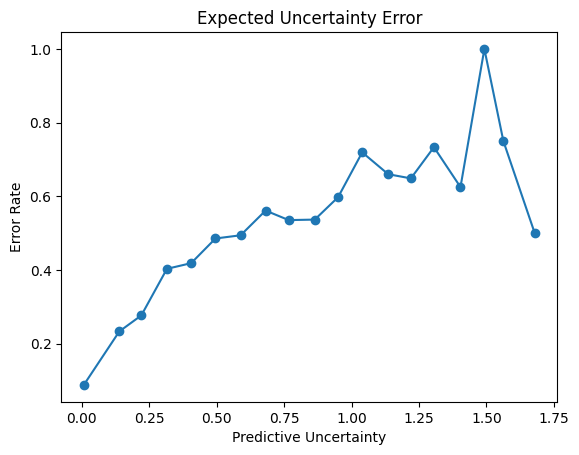

In [13]:
predictive_uncertainty = predictive_entropy(all_outputs)
errors = (all_preds != all_labels).astype(float)

n_bins = 20
bins = np.linspace(predictive_uncertainty.min(), predictive_uncertainty.max(), n_bins)
bin_idx = np.digitize(predictive_uncertainty, bins)

bin_uncertainty = []
bin_error = []
for b in range(1, n_bins):
    mask = bin_idx == b
    if mask.sum() > 0:
        bin_uncertainty.append(predictive_uncertainty[mask].mean())
        bin_error.append(errors[mask].mean())

unc_min = predictive_uncertainty.min()
unc_max = predictive_uncertainty.max()
unc_normalized = [(u - unc_min) / (unc_max - unc_min) for u in bin_uncertainty]
bin_sizes = [((bin_idx == b)).sum() for b in range(1, n_bins) if (bin_idx == b).sum() > 0]

uce = sum(
    s * abs(e - u)
    for s, e, u in zip(bin_sizes, bin_error, unc_normalized)
) / len(all_labels)

print(f'UCE : {100*uce:.2f}%')

plt.plot(bin_uncertainty, bin_error, marker='o')
plt.xlabel('Predictive Uncertainty')
plt.ylabel("Error Rate")
plt.title('Expected Uncertainty Error')
plt.show()

### Adaptive Uncertainty Calibration Error (AUCE)

AUCE : 10.23%


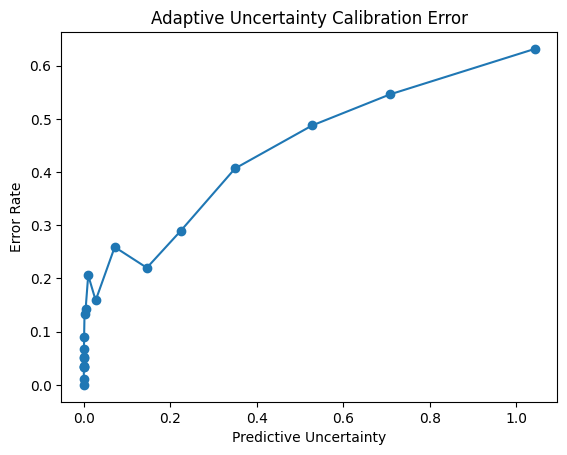

In [14]:
predictive_uncertainty = predictive_entropy(all_outputs)
errors = (all_preds != all_labels).astype(float)

n_bins = 20
# bins adaptatifs — même nombre d'exemples par bin
bin_boundaries = np.percentile(predictive_uncertainty, np.linspace(0, 100, n_bins + 1))
bin_idx = np.digitize(predictive_uncertainty, bin_boundaries)

auce_bin_uncertainty = []  # ← renommé
auce_bin_error = []        # ← renommé
for b in range(1, n_bins + 1):
    mask = bin_idx == b
    if mask.sum() > 0:
        auce_bin_uncertainty.append(predictive_uncertainty[mask].mean())
        auce_bin_error.append(errors[mask].mean())

unc_min = predictive_uncertainty.min()
unc_max = predictive_uncertainty.max()
auce_unc_normalized = [(u - unc_min) / (unc_max - unc_min) for u in auce_bin_uncertainty]
auce_bin_sizes = [(bin_idx == b).sum() for b in range(1, n_bins + 1) if (bin_idx == b).sum() > 0]

auce = sum(
    s * abs(e - u)
    for s, e, u in zip(auce_bin_sizes, auce_bin_error, auce_unc_normalized)
) / len(all_labels)

print(f'AUCE : {100*auce:.2f}%')

plt.plot(auce_bin_uncertainty, auce_bin_error, marker='o')
plt.xlabel('Predictive Uncertainty')
plt.ylabel("Error Rate")
plt.title('Adaptive Uncertainty Calibration Error')
plt.show()

### Plot l'uncertainty par classe

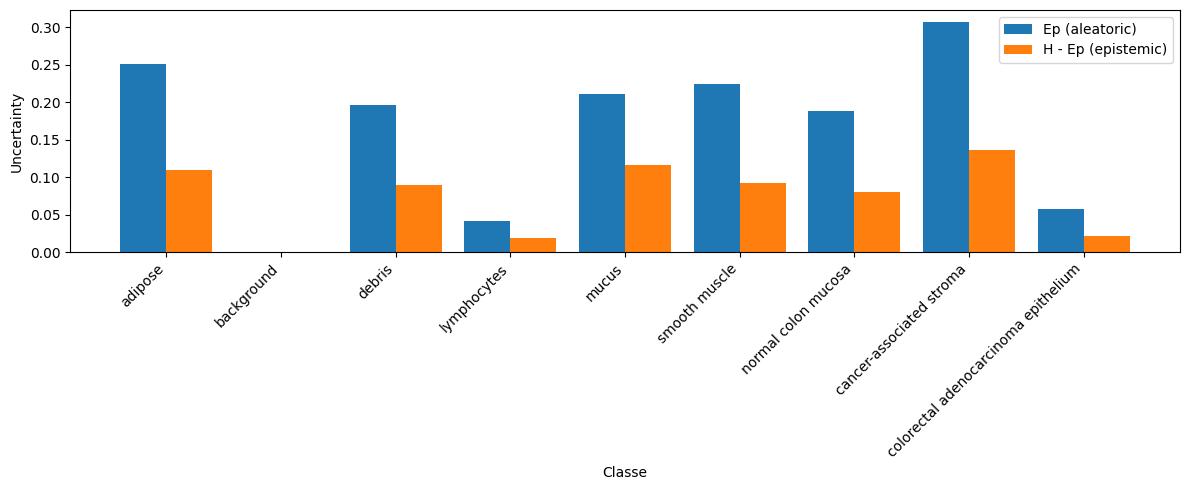

In [15]:
n_classes = len(class_names)

mean_pred_uncertainty = []
mean_model_uncertainty = []

for c in range(n_classes):
    mask = (all_labels == c)
    mean_pred_uncertainty.append(predictive_uncertainty[mask].mean())
    mean_model_uncertainty.append(model_uncertainty[mask].mean())

x = np.arange(n_classes)
width = 0.4

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, mean_pred_uncertainty, width, label='Ep (aleatoric)')
plt.bar(x + width/2, mean_model_uncertainty, width, label='H - Ep (epistemic)')
plt.xlabel('Classe')
plt.ylabel('Uncertainty')
plt.xticks(x, class_names.values(), rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### Plot TrainLoss et ValLoss

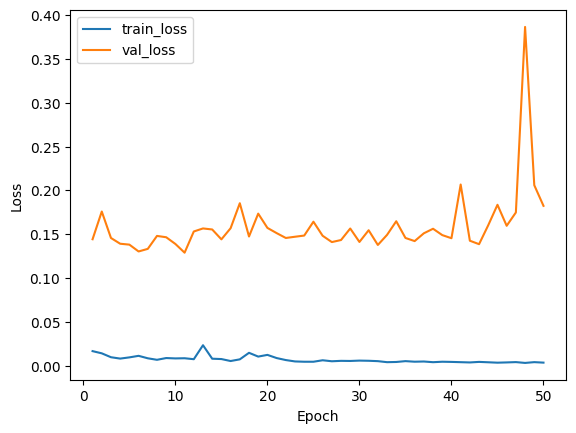

In [16]:
plt.plot(range(1, len(train_losses) + 1), train_losses, label='train_loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Plot la calibration

ECE : 13.13 %


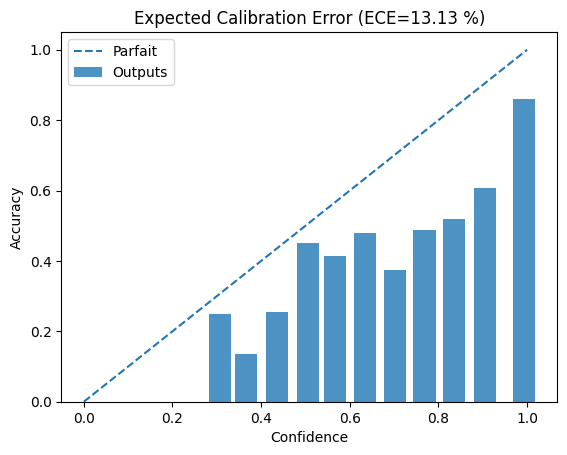

In [17]:
mean_probs = all_outputs.mean(axis=0)  # (N, classes)
confidences = mean_probs.max(axis=-1)  # confidence = proba max
correct = (all_preds == all_labels).astype(float)

n_bins = 15
bin_boundaries = np.linspace(0, 1, n_bins + 1)
bin_acc = []
bin_conf = []
bin_sizes = []

for i in range(n_bins):
    mask = (confidences >= bin_boundaries[i]) & (confidences < bin_boundaries[i+1])
    if mask.sum() > 0:
        bin_acc.append(correct[mask].mean())
        bin_conf.append(confidences[mask].mean())
        bin_sizes.append(mask.sum())

#ECE
ece = sum(s * abs(a - c) for s, a, c in zip(bin_sizes, bin_acc, bin_conf)) / len(all_labels)
print(f'ECE : {100 * ece:.2f} %')

#Reliability diagram
plt.bar(bin_conf, bin_acc, width=0.05, alpha=0.8, label='Outputs')
plt.plot([0,1],[0,1], '--', label='Parfait')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.title(f'Expected Calibration Error (ECE={100 * ece:.2f} %)')
plt.legend()
plt.show()

### Adaptive Certainty Error (ACE)

ACE : 13.13%


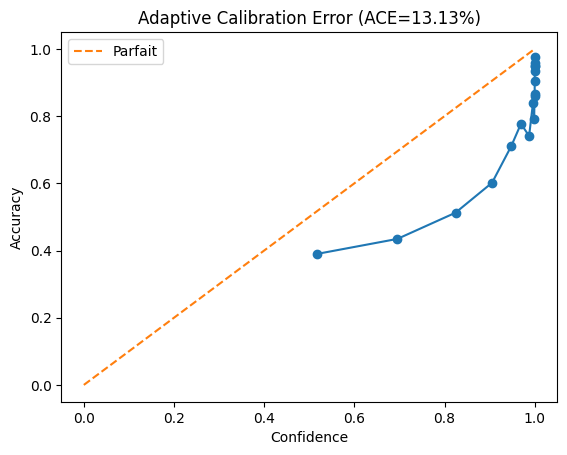

In [18]:
mean_probs = all_outputs.mean(axis=0)       # (N, classes)
confidences = mean_probs.max(axis=-1)        # confiance = proba max
correct = (all_preds == all_labels).astype(float)

n_bins = 20
# bins adaptatifs — même nombre d'exemples par bin
bin_boundaries = np.percentile(confidences, np.linspace(0, 100, n_bins + 1))
bin_idx = np.digitize(confidences, bin_boundaries)

ace_bin_confidence = []
ace_bin_accuracy = []
for b in range(1, n_bins + 1):
    mask = bin_idx == b
    if mask.sum() > 0:
        ace_bin_confidence.append(confidences[mask].mean())
        ace_bin_accuracy.append(correct[mask].mean())

ace_bin_sizes = [(bin_idx == b).sum() for b in range(1, n_bins + 1) if (bin_idx == b).sum() > 0]

ace = sum(
    s * abs(a - c)
    for s, a, c in zip(ace_bin_sizes, ace_bin_accuracy, ace_bin_confidence)
) / len(all_labels)

print(f'ACE : {100*ace:.2f}%')

plt.plot(ace_bin_confidence, ace_bin_accuracy, marker='o')
plt.plot([0, 1], [0, 1], '--', label='Parfait')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.title(f'Adaptive Calibration Error (ACE={100*ace:.2f}%)')
plt.legend()
plt.show()

### Plot Uncertain when Inaccurate + Confidence vs Accuracy

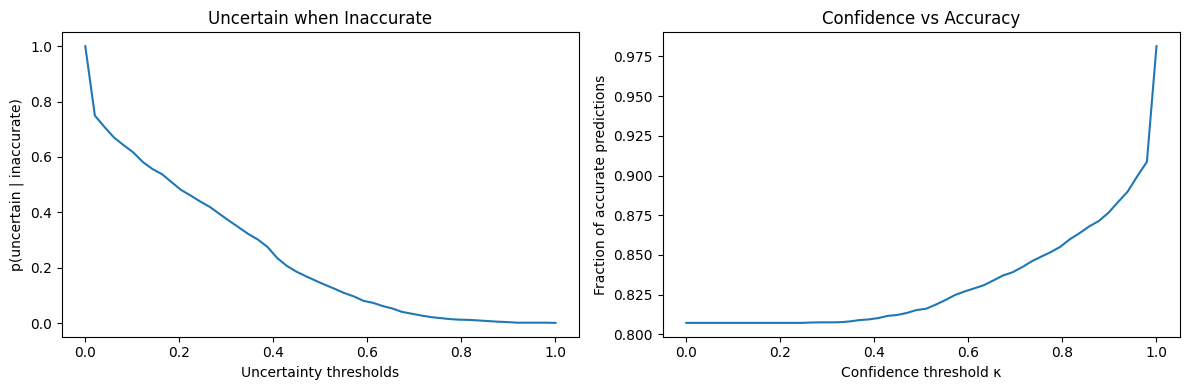

In [19]:
# Normalise les incertitudes entre 0 et 1
unc_norm = predictive_uncertainty / predictive_uncertainty.max()

thresholds_unc = np.linspace(0, 1, 50)
uncertain_when_inaccurate = []
inaccurate = (correct == 0)

for kappa in thresholds_unc:
    above_threshold = unc_norm >= kappa
    if inaccurate.sum() > 0:
        uncertain_when_inaccurate.append(
            (inaccurate & above_threshold).sum() / inaccurate.sum()
        )
    else:
        uncertain_when_inaccurate.append(np.nan)

thresholds_conf = np.linspace(0, 1, 50)
confident_when_accurate = []
for kappa in thresholds_conf:
    mask = confidences >= kappa
    if mask.sum() > 0:
        confident_when_accurate.append(correct[mask].mean())
    else:
        confident_when_accurate.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(thresholds_unc, uncertain_when_inaccurate)
axes[0].set_xlabel('Uncertainty thresholds')
axes[0].set_ylabel('p(uncertain | inaccurate)')
axes[0].set_title('Uncertain when Inaccurate')

axes[1].plot(thresholds_conf, confident_when_accurate)
axes[1].set_xlabel('Confidence threshold κ')
axes[1].set_ylabel('Fraction of accurate predictions')
axes[1].set_title('Confidence vs Accuracy')

plt.tight_layout()
plt.show()

### Exporte les résultats

0.15587316
[tracker] ✓ Run 'run_effnet_32_layers_lr0.005_bayesian' sauvegardé
          JSON → /home/a992250/bnn/bnn_runs.json
          CSV  → /home/a992250/bnn/bnn_runs.csv
          Accuracy=80.72%  ECE=13.13%  H=0.1559  MI=0.0708
Nom                                             Acc%   ECE%       H      MI  σ prior  ρ_init  MOPED
-----------------------------------------------------------------------------------------------
run_effnet_32_layers_lr0.005_bayesian          80.72  13.13  0.1559  0.0708     1.0    -3.0  oui
run_effnet_201_layers_bayesian                 81.50   4.73  0.3576  0.1736     1.0    -3.0  oui
run_effnet_175_layers_bayesian                 79.87  10.58  0.2414  0.1130     1.0    -3.0  oui
run_effnet_162_layers_bayesian                 79.53  12.94  0.1903  0.0745     1.0    -3.0  oui
run_effnet_188_layers_bayesian                 79.61   8.86  0.2928  0.1395     1.0    -3.0  oui
run_effnet_97_layers_bayesian                  81.35  14.59  0.1028  0.0224     1.0  

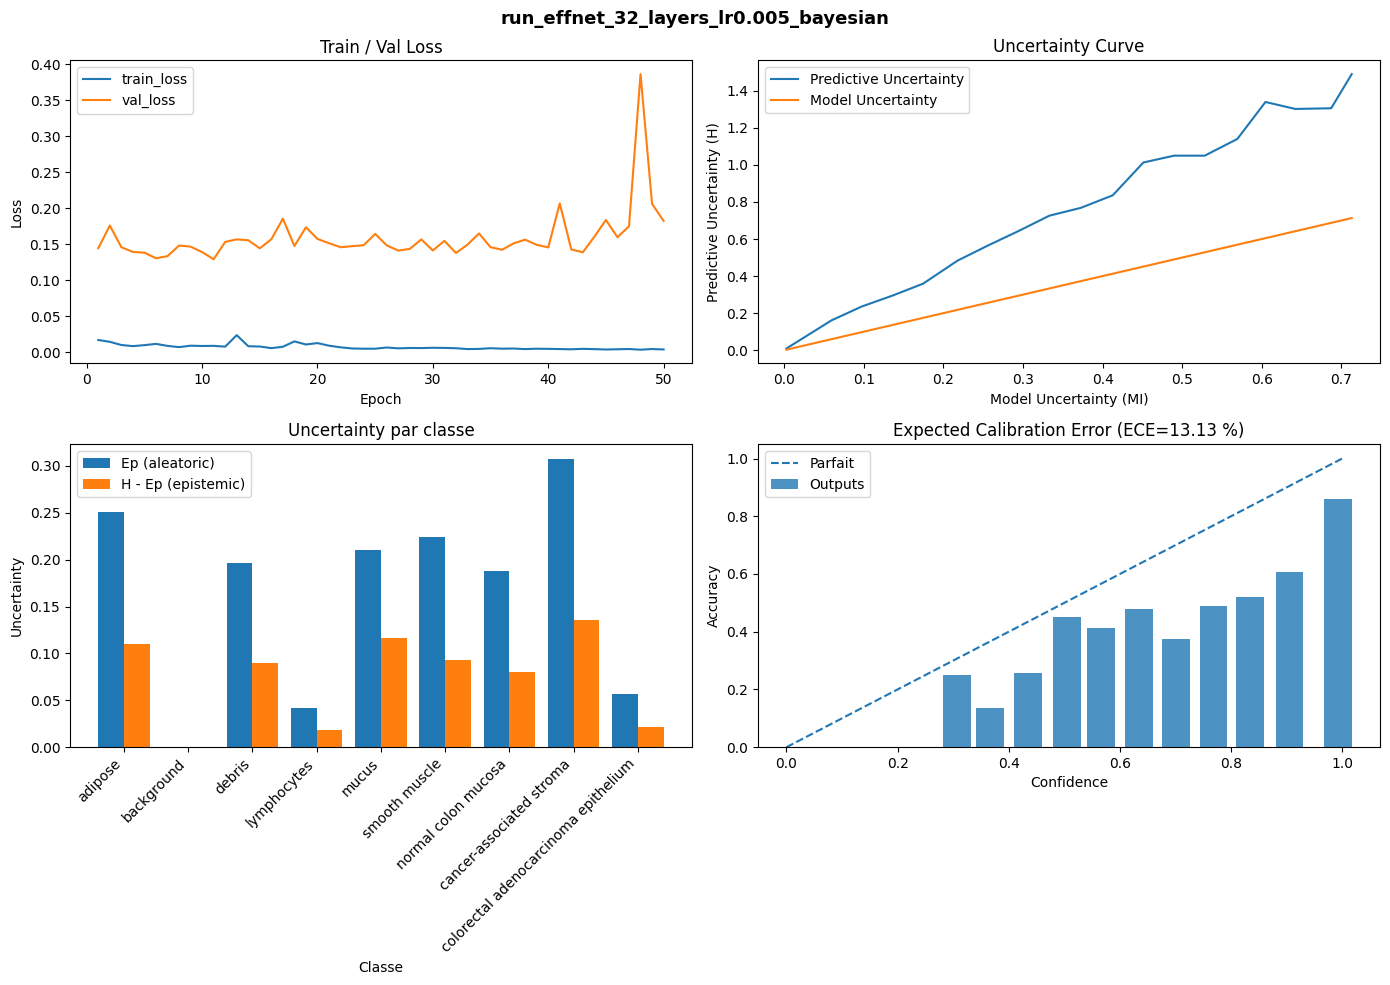

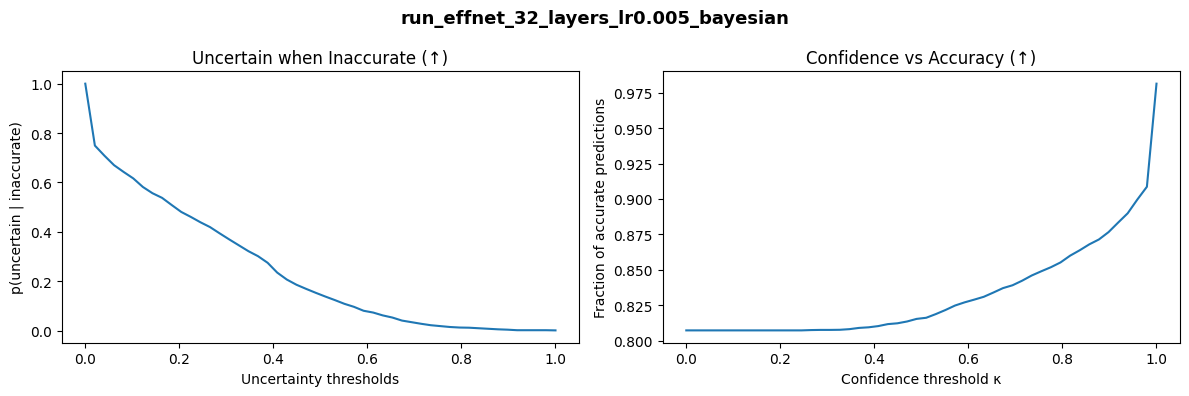

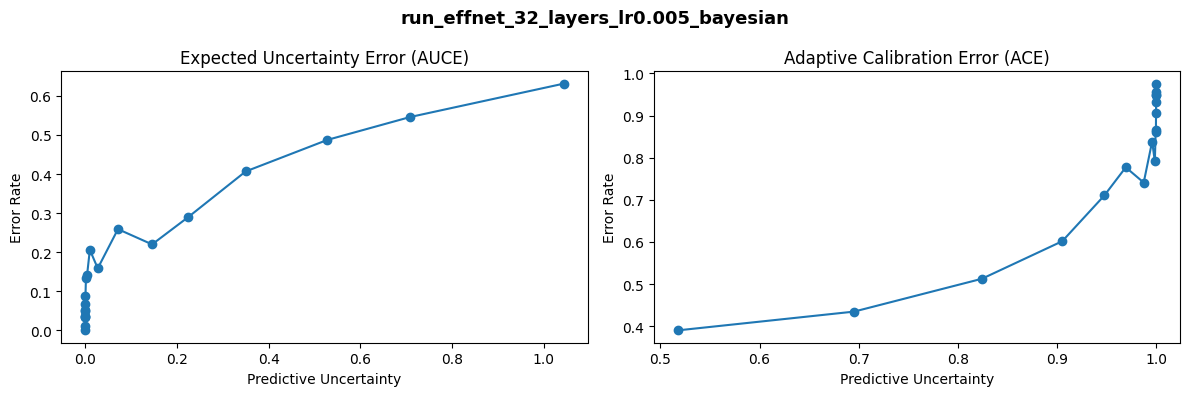

In [20]:
import importlib
import jupyterToTracker
importlib.reload(jupyterToTracker)

from jupyterToTracker import log_run, print_summary, plot_run

# Calcule les accuracy par classe en % d'abord
class_acc_pct = {
    name: 100 * correct_pred[name] / total_pred[name]
    for name in correct_pred
}

print(predictive_uncertainty.mean())

name=f"run_effnet_{nb_couches}_layers_lr{learning_rate}_bayesian"

log_run(
    name=name,
    # hyperparamètres
    lr=learning_rate,
    epochs=nb_epoch,
    batch_size=batch_size,
    num_monte_carlo=num_monte_carlo,
    milestones=milestones,
    gamma=gamma,
    # prior
    prior_mu=const_bnn_prior_parameters["prior_mu"],
    prior_sigma=const_bnn_prior_parameters["prior_sigma"],
    posterior_mu_init=const_bnn_prior_parameters["posterior_mu_init"],
    posterior_rho_init=const_bnn_prior_parameters["posterior_rho_init"],
    bnn_type=const_bnn_prior_parameters["type"],
    moped_enable=const_bnn_prior_parameters["moped_enable"],
    moped_delta=const_bnn_prior_parameters["moped_delta"],
    # métriques
    test_accuracy=test_acc * 100,
    train_accuracy=train_acc * 100,
    val_accuracy=val_acc * 100,
    ece=ece * 100,
    uce=uce * 100,
    ace = ace * 100,
    mean_predictive_entropy=float(predictive_uncertainty.mean()),
    mean_mutual_information=float(model_uncertainty.mean()),
    # classes
    class_accuracy=class_acc_pct,
    notes="premier test baseline",
    # plots
    train_losses=train_losses,
    val_losses=val_losses,
    mean_pred_uncertainty_per_class=mean_pred_uncertainty,
    mean_model_uncertainty_per_class=mean_model_uncertainty,
    uncertainty_bin_model=model_means,
    uncertainty_bin_pred=pred_means,
    calib_bin_conf=bin_conf,
    calib_bin_acc=bin_acc,
    calib_bin_sizes=bin_sizes,
    thresholds_unc=thresholds_unc.tolist(),
    uncertain_when_inaccurate=uncertain_when_inaccurate,
    thresholds_conf=thresholds_conf.tolist(),
    confident_when_accurate=confident_when_accurate,
    uce_bin_uncertainty=bin_uncertainty,   # du plot UCE
    uce_bin_error=bin_error,
    ace_bin_confidence=ace_bin_confidence,
    ace_bin_accuracy=ace_bin_accuracy,
    auce_bin_uncertainty=auce_bin_uncertainty,
    auce_bin_error=auce_bin_error,             
)

print_summary()
plot_run(name)